# T-SNE Evaluation of Latent Space (Z)
Mục tiêu của Notebook này:
1. Lấy ảnh thật từ Dataset và trích xuất $\mu, \sigma$ thông qua Encoder.
2. Tạo ảnh trộn ở Pixel Space ($x_{mix}$) và lấy mẫu $z$ tương ứng.
3. Trộn đặc trưng ở Latent Space (tính $\mu_{mix}, \sigma_{mix}$ từ $\mu_1, \mu_2$) và lấy mẫu $z$.
4. Dùng thuật toán T-SNE giảm chiều xuống 2D để đánh giá sự khác biệt giữa trộn ở Pixel và trộn ở Latent.
5. Giải mã các vector $z$ thành ảnh.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from omegaconf import OmegaConf

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.models.unet_model import UNetPalmModel
from src.models.palm_model import ProbabilisticPalmModel
from src.datasets import DatasetFactory
from torch.utils.data import DataLoader

In [2]:
# 1. Setup Config & Device
config_path = "E:/palm/logs/version_0/config_backup.yaml"
config = OmegaConf.load(config_path)
config = OmegaConf.to_container(config, resolve=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Sử dụng device: {device}')

Sử dụng device: cpu


In [3]:
# 2. Load Checkpoint & Model
model_config = config.get('model', {})
if model_config.get('type') == 'unet':
    model = UNetPalmModel(model_config).to(device)
else:
    model = ProbabilisticPalmModel(model_config).to(device)

checkpoint_path = config.get('checkpoint', '')
checkpoint_path = "E:/palm/logs/version_0/checkpoints\last.ckpt"
if checkpoint_path and os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
    clean_state_dict = {k[6:] if k.startswith('model.') else k: v for k, v in state_dict.items()}
    model.load_state_dict(clean_state_dict, strict=False)
    print('Đã tải checkpoint thành công!')
else:
    print('Không tìm thấy checkpoint. Chạy với trọng số ngẫu nhiên!')
model.eval()

Đã tải checkpoint thành công!


UNetPalmModel(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): DownBlock(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3

E:/palm/data/Tongji
Loaded TongjiDataset (mixed mode) - Val: 2400 samples.


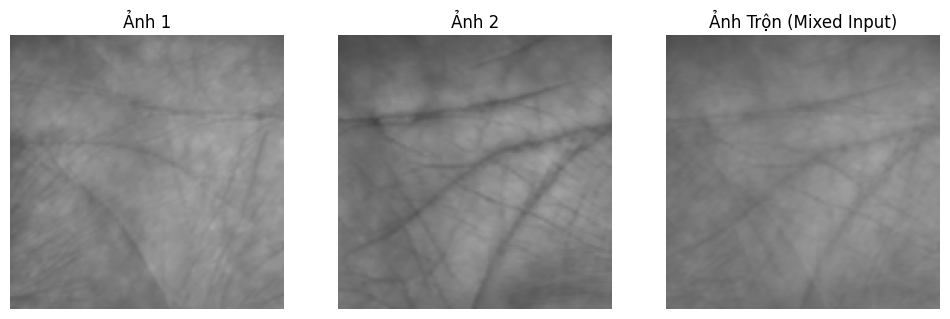

In [4]:
# 3. Load Dataset & Lấy 2 ảnh mẫu
dataset_config = config.get('dataset', {})
data_dir = dataset_config.get('data_dir', '../data/collect')
dataset_name = dataset_config.get('name', 'OwnOriginalDataset')

print(data_dir)
dataset = DatasetFactory.create(dataset_name, data_dir=data_dir, config=dataset_config, is_train=False)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

batch_x, batch_y = next(iter(dataloader))
x1 = batch_x[0:1].to(device)
x2 = batch_x[1:2].to(device)

# Trộn 2 ảnh ở đầu vào (Pixel space)
alpha = 0.5
x_mix = (1 - alpha) * x1 + alpha * x2

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow((x1[0].permute(1, 2, 0).cpu().numpy() + 1) / 2)
axs[0].set_title('Ảnh 1')
axs[0].axis('off')

axs[1].imshow((x2[0].permute(1, 2, 0).cpu().numpy() + 1) / 2)
axs[1].set_title('Ảnh 2')
axs[1].axis('off')

axs[2].imshow((x_mix[0].permute(1, 2, 0).cpu().numpy() + 1) / 2)
axs[2].set_title('Ảnh Trộn (Mixed Input)')
axs[2].axis('off')
plt.show()

In [5]:
# 4. Trích xuất mu, sigma và Sample N mẫu
N = 500

def sample_z(x, num_samples):
    with torch.no_grad():
        out = model(x, decode=False)
        mu = out['mu']
        logvar = torch.clamp(out['logvar'], min=-20, max=2.0)
        std = torch.exp(0.5 * logvar)
        
        eps = torch.randn(num_samples, mu.size(1), device=device)
        z_samples = mu + eps * std
        return z_samples.cpu().numpy()

def sample_z_latent_mix(x1, x2, num_samples, alpha=0.5):
    with torch.no_grad():
        out1 = model(x1, decode=False)
        out2 = model(x2, decode=False)
        mu_mix = (1 - alpha) * out1['mu'] + alpha * out2['mu']
        logvar1 = torch.clamp(out1['logvar'], min=-20, max=2.0)
        logvar2 = torch.clamp(out2['logvar'], min=-20, max=2.0)
        logvar_mix = (1 - alpha) * logvar1 + alpha * logvar2
        std_mix = torch.exp(0.5 * logvar_mix)
        
        eps = torch.randn(num_samples, mu_mix.size(1), device=device)
        z_samples = mu_mix + eps * std_mix
        return z_samples.cpu().numpy()

print(f"Tiến hành sample {N} vector z cho mỗi ảnh...")
z1 = sample_z(x1, N)
z2 = sample_z(x2, N)
z_mix_pixel = sample_z(x_mix, N)
z_mix_latent = sample_z_latent_mix(x1, x2, N, alpha=0.5)

z_all = np.concatenate([z1, z2, z_mix_pixel, z_mix_latent], axis=0)
labels = np.concatenate([np.zeros(N), np.ones(N), np.ones(N)*2, np.ones(N)*3])
print("Hoàn tất sampling. Tổng số điểm z:", z_all.shape)

Tiến hành sample 500 vector z cho mỗi ảnh...
Hoàn tất sampling. Tổng số điểm z: (2000, 64)


In [6]:
# 5. Chạy thuật toán T-SNE để giảm chiều dữ liệu
print('Đang chạy thuật toán T-SNE (có thể mất chút thời gian)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(z_all)
print('T-SNE đã chạy xong!')

Đang chạy thuật toán T-SNE (có thể mất chút thời gian)...
T-SNE đã chạy xong!


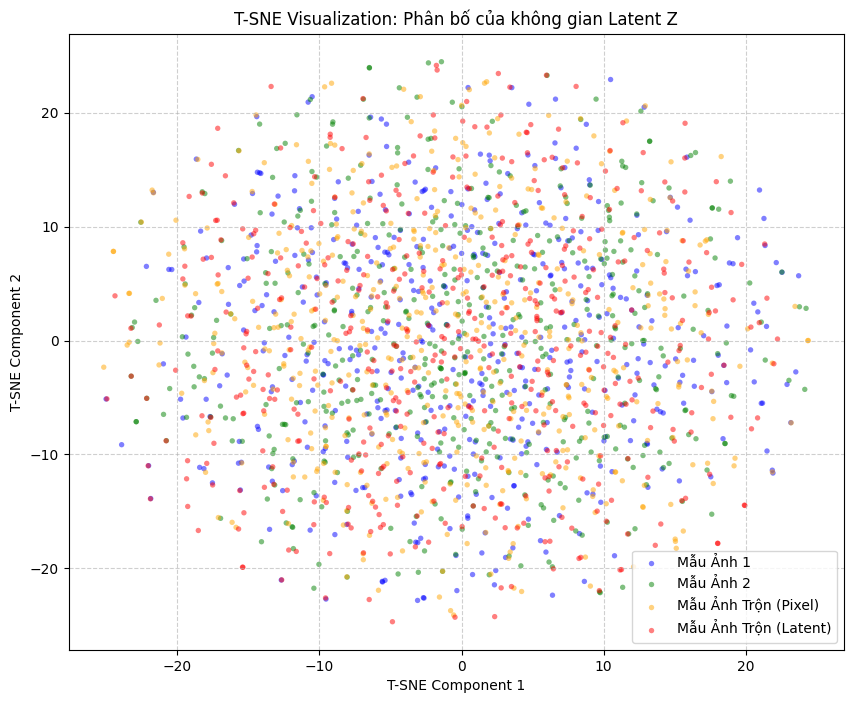

In [7]:
# 6. Trực quan hóa phân bố Z
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red']
names = ['Mẫu Ảnh 1', 'Mẫu Ảnh 2', 'Mẫu Ảnh Trộn (Pixel)', 'Mẫu Ảnh Trộn (Latent)']

for i in range(4):
    mask = (labels == i)
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], c=colors[i], label=names[i], alpha=0.5, s=15, edgecolors='none')

plt.title('T-SNE Visualization: Phân bố của không gian Latent Z')
plt.xlabel('T-SNE Component 1')
plt.ylabel('T-SNE Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

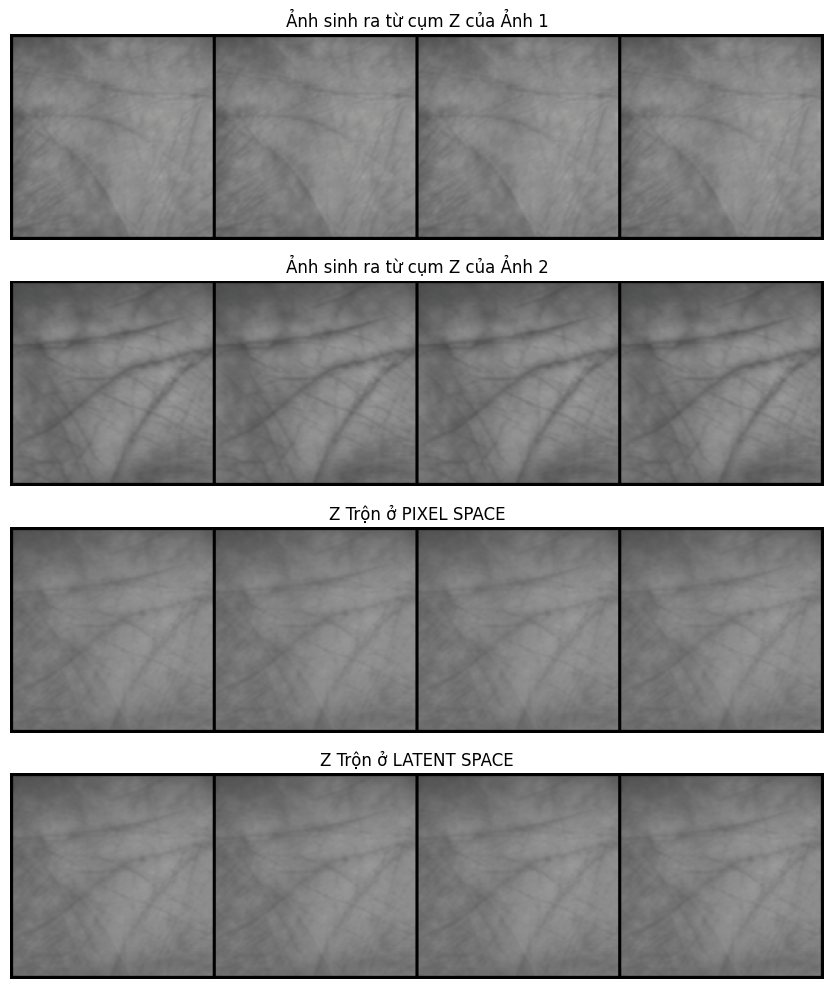

In [9]:
# 7. Sinh ảnh (Decode) từ một vài vector z ngẫu nhiên của 4 phân bố
import random
import torchvision.utils as vutils

def decode_z(model, z_batch, x_skip_batch):
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'decode_from_z_and_x'):
            x_hat = model.decode_from_z_and_x(z_batch, x_skip_batch)
        else:
            x_hat = model.decoder(z_batch)
        return x_hat

# Lấy ngẫu nhiên 4 mẫu z từ mỗi phân bố
indices = random.sample(range(N), 4)

z1_sample = torch.tensor(z1[indices], device=device)
z2_sample = torch.tensor(z2[indices], device=device)
z_mix_pixel_sample = torch.tensor(z_mix_pixel[indices], device=device)
z_mix_latent_sample = torch.tensor(z_mix_latent[indices], device=device)

# Decode (với U-Net ta truyền thêm skip connection tương ứng)
x1_hat = decode_z(model, z1_sample, x1.expand(4, -1, -1, -1))
x2_hat = decode_z(model, z2_sample, x2.expand(4, -1, -1, -1))
# Lưu ý: Cả Pixel mix và Latent mix đều dùng chung skip connections từ ảnh trộn Pixel
x_mix_pixel_hat = decode_z(model, z_mix_pixel_sample, x_mix.expand(4, -1, -1, -1))
x_mix_latent_hat = decode_z(model, z_mix_latent_sample, x_mix.expand(4, -1, -1, -1))

# Trực quan hóa kết quả
fig, axs = plt.subplots(4, 1, figsize=(10, 10))

def plot_tensor(ax, tensor_batch, title):
    # Tạo grid ảnh
    grid = vutils.make_grid((tensor_batch + 1) / 2.0, nrow=4).cpu().permute(1, 2, 0).numpy()
    ax.imshow(grid)
    ax.set_title(title)
    ax.axis('off')

plot_tensor(axs[0], x1_hat, "Ảnh sinh ra từ cụm Z của Ảnh 1")
plot_tensor(axs[1], x2_hat, "Ảnh sinh ra từ cụm Z của Ảnh 2")
plot_tensor(axs[2], x_mix_pixel_hat, "Z Trộn ở PIXEL SPACE")
plot_tensor(axs[3], x_mix_latent_hat, "Z Trộn ở LATENT SPACE")

plt.tight_layout()
plt.show()

In [10]:
# 7. Sinh ảnh (Decode) từ một vài vector z ngẫu nhiên của 3 phân bố
import random
import torchvision.utils as vutils

def decode_z(model, z_batch, x_skip_batch):
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'decode_from_z_and_x'):
            x_hat = model.decode_from_z_and_x(z_batch, x_skip_batch)
        else:
            x_hat = model.decoder(z_batch)
        return x_hat

# Lấy ngẫu nhiên 4 mẫu z từ mỗi phân bố
indices = random.sample(range(N), 4)

z1_sample = torch.tensor(z1[indices], device=device)
z2_sample = torch.tensor(z2[indices], device=device)
z_mix_sample = torch.tensor(z_mix[indices], device=device)

# Decode (với U-Net ta truyền thêm skip connection tương ứng)
x1_hat = decode_z(model, z1_sample, x1.expand(4, -1, -1, -1))
x2_hat = decode_z(model, z2_sample, x2.expand(4, -1, -1, -1))
x_mix_hat = decode_z(model, z_mix_sample, x_mix.expand(4, -1, -1, -1))

# Trực quan hóa kết quả
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

def plot_tensor(ax, tensor_batch, title):
    # Tạo grid ảnh
    grid = vutils.make_grid((tensor_batch + 1) / 2.0, nrow=4).cpu().permute(1, 2, 0).numpy()
    ax.imshow(grid)
    ax.set_title(title)
    ax.axis('off')

plot_tensor(axs[0], x1_hat, "Ảnh sinh ra từ cụm Z của Ảnh 1")
plot_tensor(axs[1], x2_hat, "Ảnh sinh ra từ cụm Z của Ảnh 2")
plot_tensor(axs[2], x_mix_hat, "Ảnh sinh ra từ cụm Z của Ảnh Trộn")

plt.tight_layout()
plt.show()


NameError: name 'z_mix' is not defined